In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc("font", family = "Malgun Gothic")
sns.set(font="Malgun Gothic", 
rc={"axes.unicode_minus":False}, style='white')

# # 한글 폰트 설정 (Mac)
# plt.rc('font', family='AppleGothic')
# # 마이너스 기호 깨짐 방지
# plt.rcParams['axes.unicode_minus'] = False

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   지점                  1077 non-null   int64  
 1   지점명                 1077 non-null   object 
 2   일시                  1077 non-null   object 
 3   평균기온(°C)            1077 non-null   float64
 4   평균현지기압(hPa)         1077 non-null   float64
 5   평균해면기압(hPa)         1077 non-null   float64
 6   평균수증기압(hPa)         1077 non-null   float64
 7   평균상대습도(%)           1077 non-null   float64
 8   월합강수량(00~24h만)(mm)  1077 non-null   float64
 9   평균풍속(m/s)           1077 non-null   float64
 10  일조율(%)              1077 non-null   float64
 11  최심적설(cm)            1077 non-null   float64
 12  평균지면온도(°C)          1077 non-null   float64
 13  years               1077 non-null   int64  
 14  month               1077 non-null   int64  
 15  시도                  1077 non-null   object 
 16  시군구   

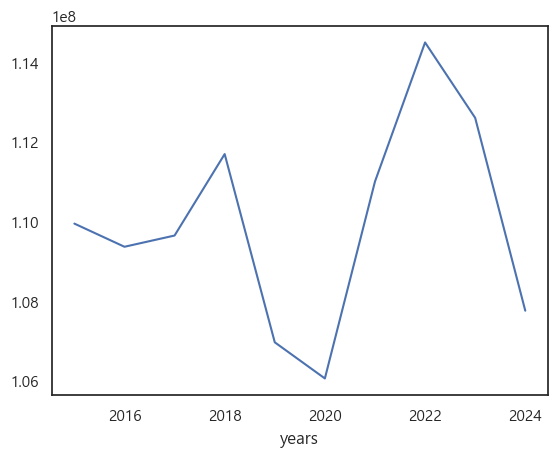

In [2]:
gangwon_total = pd.read_csv('./data/merge_file_gangwon/합 계_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_total = gangwon_total[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_total.info()
gr_year = gangwon_total.groupby(['years'])['전력량'].mean()
gr_year.plot(x='years', y='전력량')
plt.show()

<Axes: xlabel='평균기온(°C)', ylabel='전력량'>

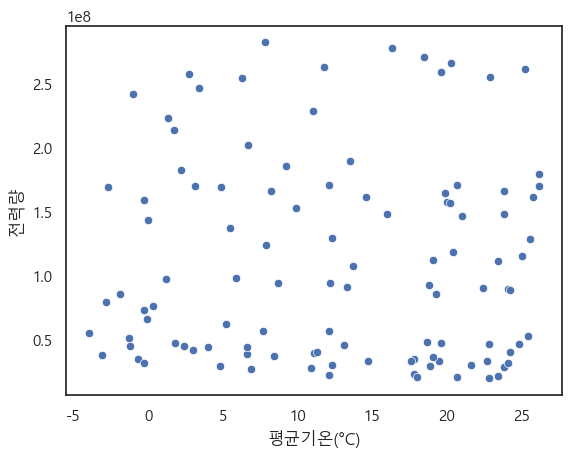

In [3]:
# 2015년 강원도의 전력량 대비 온도 비교 그래프
gangwon_2015 = gangwon_total[gangwon_total['years']==2015]
sns.scatterplot(data=gangwon_2015,x='평균기온(°C)',y='전력량')


array([<Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>,
       <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>,
       <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>,
       <Axes: xlabel='전력량'>], dtype=object)

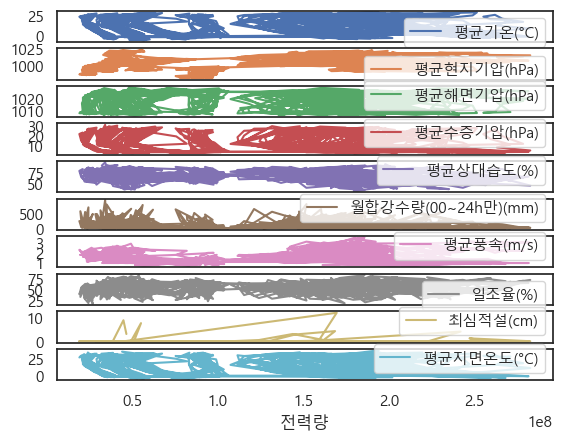

In [4]:
# 전체 강원도의 전력 별 날씨 컬럼 데이터 (비선형)
import matplotlib.pyplot as plt
gangwon_total.plot(y=['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)','평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)','최심적설(cm)', '평균지면온도(°C)'],x='전력량',
                   label=['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)','평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)','최심적설(cm)', '평균지면온도(°C)'],subplots=True)

In [5]:
gangwon_total.columns

gangwon_total['HDD'] = (18 - gangwon_total['평균기온(°C)']).clip(lower=0)
gangwon_total['CDD'] = (gangwon_total['평균기온(°C)'] - 24).clip(lower=0)

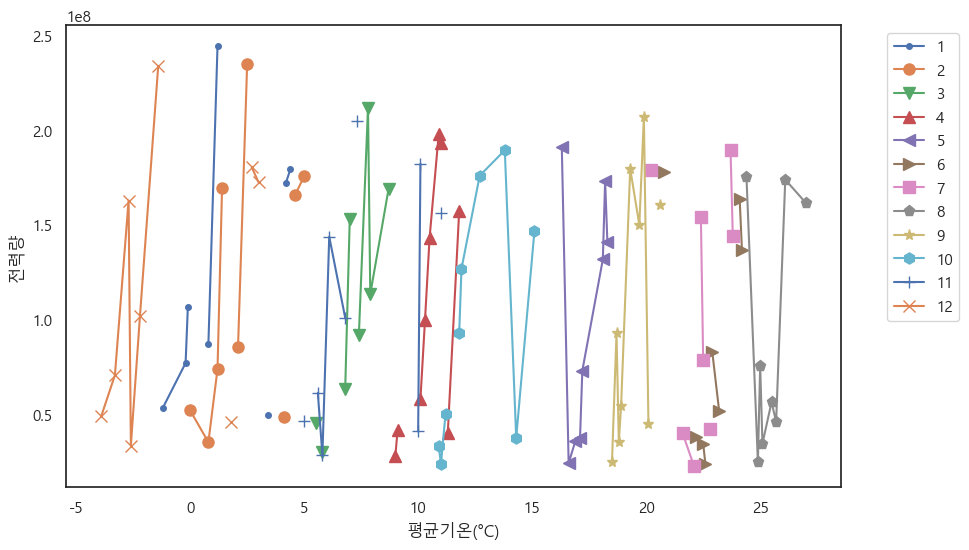

In [6]:
# 2020년 강원도 월별 평균기온의 전력량
gang_2020 = gangwon_total[gangwon_total['years']==2020]
gang_2020 = gang_2020.groupby(['month','평균기온(°C)'])['전력량'].mean().reset_index()

df_pivoted = gang_2020.pivot(index='평균기온(°C)', columns='month', values='전력량')

markers = ['.', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', '+', 'x']

ax = df_pivoted.plot(kind='line', figsize=(10, 6))
for i, line in enumerate(ax.get_lines()):
    if i < len(markers):
        line.set_marker(markers[i])
        line.set_markersize(8)  # 마커 크기 조절 (선택사항)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례 위치 조정
plt.ylabel('전력량')
plt.show()

     month  years           전력량
0        1   2015  1.283634e+08
1        1   2016  1.240950e+08
2        1   2017  1.237394e+08
3        1   2018  1.297475e+08
4        1   2019  1.272076e+08
..     ...    ...           ...
115     12   2020  1.165143e+08
116     12   2021  1.231675e+08
117     12   2022  1.154426e+08
118     12   2023  1.169788e+08
119     12   2024  1.138095e+08

[120 rows x 3 columns]


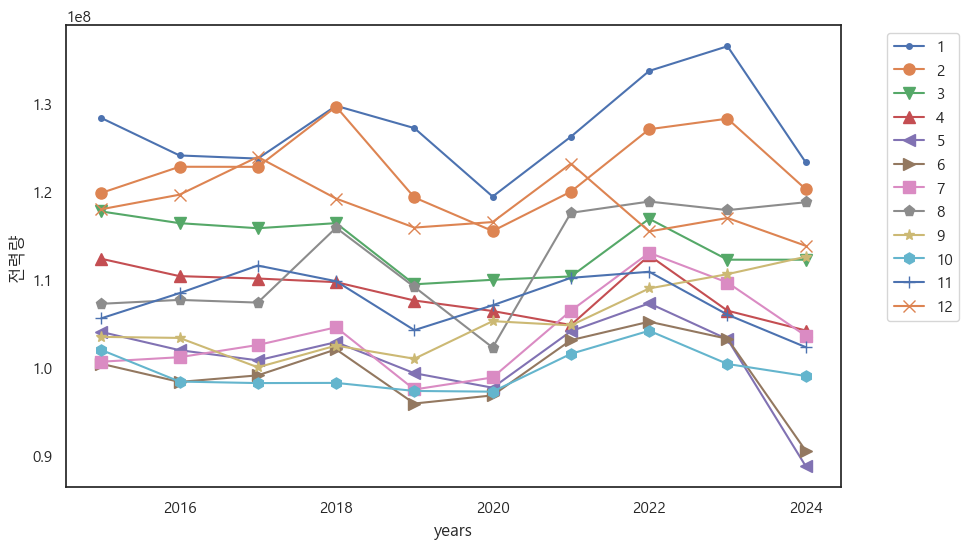

In [7]:
# 2020년 각 연도별 월 평균 전력량 비교
gang_2020 = gangwon_total[gangwon_total['years']==2020]
test = gangwon_total.groupby(['month','years'])['전력량'].mean().reset_index()
print(test)

df_pivoted = test.pivot(index='years', columns='month', values='전력량')

markers = ['.', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', '+', 'x']

ax = df_pivoted.plot(kind='line', figsize=(10, 6))
for i, line in enumerate(ax.get_lines()):
    if i < len(markers):
        line.set_marker(markers[i])
        line.set_markersize(8)  # 마커 크기 조절 (선택사항)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례 위치 조정
plt.ylabel('전력량')
plt.show()

### 교육용 농업용,산업용, 가로등, 심야, 일반용, 주택용

In [13]:
gangwon_general = pd.read_csv('./data/merge_file_gangwon/일반용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_house = pd.read_csv('./data/merge_file_gangwon/주택용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_light = pd.read_csv('./data/merge_file_gangwon/가로등_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_farm = pd.read_csv('./data/merge_file_gangwon/농사용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_edu = pd.read_csv('./data/merge_file_gangwon/교육용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_night = pd.read_csv('./data/merge_file_gangwon/심 야_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_industry = pd.read_csv('./data/merge_file_gangwon/산업용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_total = pd.read_csv('./data/merge_file_gangwon/합 계_elect_temp_gangwon.csv',encoding='utf-8')


gangwon_general = gangwon_general[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_general = gangwon_general.rename({'전력량':'전력사용량'},axis=1)


gangwon_house = gangwon_house[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_house = gangwon_house.rename({'전력량':'전력사용량'},axis=1)


gangwon_light = gangwon_light[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_light = gangwon_light.rename({'전력량':'전력사용량'},axis=1)


gangwon_farm = gangwon_farm[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_farm = gangwon_farm.rename({'전력량':'전력사용량'},axis=1)


gangwon_edu = gangwon_edu[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_edu = gangwon_edu.rename({'전력량':'전력사용량'},axis=1)

gangwon_night = gangwon_night[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_night = gangwon_night.rename({'전력량':'전력사용량'},axis=1)



gangwon_industry = gangwon_industry[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_industry = gangwon_industry.rename({'전력량':'전력사용량'},axis=1)

gangwon_total = gangwon_total[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량','HDD','CDD']]
gangwon_total = gangwon_total.rename({'전력량':'전력사용량'},axis=1)


In [14]:
# gangwon_night['계약종별'][0]
# gangwon_general
# gangwon_house 
# gangwon_light 
# gangwon_farm 
# gangwon_edu 
# gangwon_night
gangwon_total

,지점,지점명,일시,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),...,최심적설(cm),평균지면온도(°C),years,month,시도,시군구,계약종별,전력사용량,HDD,CDD
0,90,속초,2015-01,1.8,1019.8,1022.1,3.7,52.0,8.7,2.2,...,3.0,1.2,2015,1,강원도,속초시,합 계,46763124,16.2,0.0
1,90,속초,2015-02,2.4,1018.0,1020.2,4.4,59.0,32.1,2.5,...,8.7,2.3,2015,2,강원도,속초시,합 계,45037434,15.6,0.0
2,90,속초,2015-03,6.6,1017.0,1019.2,5.2,52.0,8.0,2.5,...,0.0,8.5,2015,3,강원도,속초시,합 계,38830684,11.4,0.0
3,90,속초,2015-04,11.1,1014.0,1016.2,8.1,69.0,74.2,2.5,...,0.0,12.8,2015,4,강원도,속초시,합 계,39041260,6.9,0.0
4,90,속초,2015-05,17.8,1005.8,1007.9,11.5,61.0,9.2,2.4,...,0.0,23.7,2015,5,강원도,속초시,합 계,34351238,0.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,212,홍천,2024-08,27.5,992.0,1007.7,27.9,78.0,106.9,1.0,...,0.0,30.6,2024,8,강원도,홍천군,합 계,67581225,0.0,3.5
1073,212,홍천,2024-09,23.1,998.1,1014.1,22.4,80.0,171.4,0.9,...,0.0,25.8,2024,9,강원도,홍천군,합 계,62535720,0.0,0.0
1074,212,홍천,2024-10,14.1,1004.4,1021.1,12.9,81.0,106.2,0.7,...,0.0,16.7,2024,10,강원도,홍천군,합 계,52157240,3.9,0.0
1075,212,홍천,2024-11,7.2,1005.6,1022.9,7.8,75.0,43.3,0.6,...,0.0,7.9,2024,11,강원도,홍천군,합 계,56965327,10.8,0.0


Index(['지점', '지점명', '일시', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
       '평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',
       '최심적설(cm)', '평균지면온도(°C)', 'years', 'month', '시도', '시군구', '계약종별',
       '전력사용량', 'HDD', 'CDD'],
      dtype='object')


dict_keys(['주택용', '일반용', '교육용', '산업용', '농사용', '심야', '가로등', '합 계'])

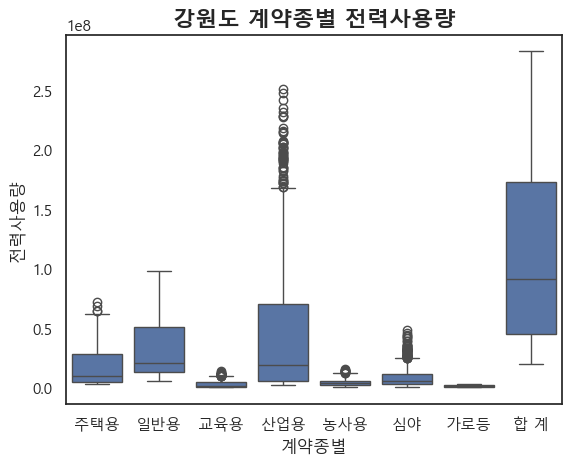

In [15]:
dfs = {
    '주택용': gangwon_house,
    '일반용': gangwon_general,
    '교육용': gangwon_edu,
    '산업용': gangwon_industry,
    '농사용': gangwon_farm,
    '심야': gangwon_night,
    '가로등': gangwon_light,
    '합 계' : gangwon_total
}

all_frame = []
for name, df in dfs.items():
    temp = df.copy()
    temp['계약종별'] = name
    all_frame.append(temp)

gangwon_type = pd.concat(all_frame,ignore_index=True)
gangwon_type.groupby(['years'])['전력사용량'].mean()
sns.boxplot(data=gangwon_type, x='계약종별', y='전력사용량')
plt.title('강원도 계약종별 전력사용량',fontweight='bold', fontsize=16)
print(gangwon_type.keys())
dfs.keys()

In [ ]:
gr_year = gangwon_type.groupby(['계약종별','years'])['전력량'].mean()
gr_year
# gr_year.plot(x='계약종별', y='전력량')
# gr_year.pivot(index='계약종별', columns='years', values='전력량')
# plt.show()
